# Examine the data frame calculate_amplitudes_skipped_picks.csv

This notebook is used to check the data frame called calculate_amplitudes_skipped_picks.csv

Agentic AI was used in this notebook. 

By Hiroto Bito

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import UTCDateTime
import time
from obspy.core.stream import Stream


parent_dir = '/home/hbito/cascadia_obs_ensemble/utils'
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_client import get_waveforms

In [2]:
# Prepare the file paths
datasets_dir =  '/wd1/hbito_data/data/datasets_all_regions'
path = f'{datasets_dir}/calculate_amplitudes_skipped_picks.csv'

In [15]:
skipped_picks_df = pd.read_csv(path, index_col=False).copy()
print('len(skipped_picks_df)', len(skipped_picks_df))
skipped_picks_df.head(10)

len(skipped_picks_df) 135


,arid,orid,network,station,channel,origin_time,time_pick,starttime,endtime,reason
0,43526,3191,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:05.360000Z,2010-04-30T16:04:05.360000Z,Request failed: No Vertical Component Data Pre...
1,43666,3204,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:27.850000Z,2010-05-01T04:21:27.850000Z,Request failed: No Vertical Component Data Pre...
2,58950,4249,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:07.870000Z,2010-06-22T15:52:07.870000Z,Request failed: No Vertical Component Data Pre...
3,71607,5135,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:04:32.760000Z,2010-07-31T04:07:32.760000Z,Request failed: No Vertical Component Data Pre...
4,74595,5329,UW,SP2,*H*,2010-08-09T03:50:22.194000Z,2010-08-09T03:50:52.920000Z,2010-08-09T03:50:22.920000Z,2010-08-09T03:53:22.920000Z,Request failed: No Vertical Component Data Pre...
5,75466,5396,UW,SP2,*H*,2010-08-11T13:06:01.021000Z,2010-08-11T13:06:19.890000Z,2010-08-11T13:05:49.890000Z,2010-08-11T13:08:49.890000Z,Request failed: No Vertical Component Data Pre...
6,280169,19503,CN,BTB,*H*,2012-02-26T13:29:28.280000Z,2012-02-26T13:30:11.960000Z,2012-02-26T13:29:41.960000Z,2012-02-26T13:32:41.960000Z,Request failed: No Vertical Component Data Pre...
7,281900,19619,CN,BTB,*H*,2012-03-02T16:39:18.794000Z,2012-03-02T16:39:41.720000Z,2012-03-02T16:39:11.720000Z,2012-03-02T16:42:11.720000Z,Request failed: No Vertical Component Data Pre...
8,282415,19649,NC,KRMB,*H*,2012-03-03T16:04:55.967000Z,2012-03-03T16:05:19.520000Z,2012-03-03T16:04:49.520000Z,2012-03-03T16:07:49.520000Z,Request failed: No Vertical Component Data Pre...
9,306465,21056,CN,VGZ,*H*,2012-04-24T23:59:59.389000Z,2012-04-25T00:00:05.000000Z,2012-04-24T23:59:35.000000Z,2012-04-25T00:02:35.000000Z,Request failed: No Vertical Component Data Pre...


In [4]:
skipped_picks_df['network_station'] = skipped_picks_df['network'] + '.' + skipped_picks_df['station'] + '.'
skipped_picks_df.head()

,arid,orid,network,station,channel,origin_time,time_pick,starttime,endtime,reason,network_station
0,43526,3191,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:05.360000Z,2010-04-30T16:04:05.360000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
1,43666,3204,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:27.850000Z,2010-05-01T04:21:27.850000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
2,58950,4249,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:07.870000Z,2010-06-22T15:52:07.870000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
3,71607,5135,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:04:32.760000Z,2010-07-31T04:07:32.760000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
4,74595,5329,UW,SP2,*H*,2010-08-09T03:50:22.194000Z,2010-08-09T03:50:52.920000Z,2010-08-09T03:50:22.920000Z,2010-08-09T03:53:22.920000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.


In [5]:
len(skipped_picks_df.drop_duplicates(subset='network_station'))

20

Plot the histogram of the stations 

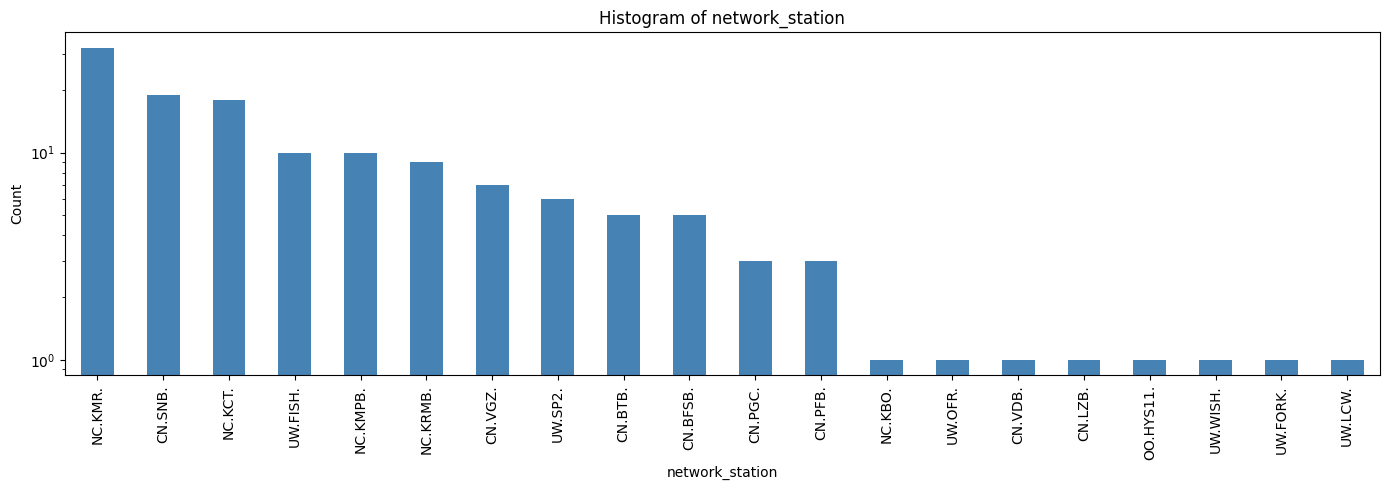

In [6]:
network_station_counts = skipped_picks_df['network_station'].value_counts()
ax = network_station_counts.plot(kind='bar', figsize=(14, 5), color='steelblue')
ax.set_title('Histogram of network_station')
ax.set_xlabel('network_station')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

Plot the histogram of the networks 

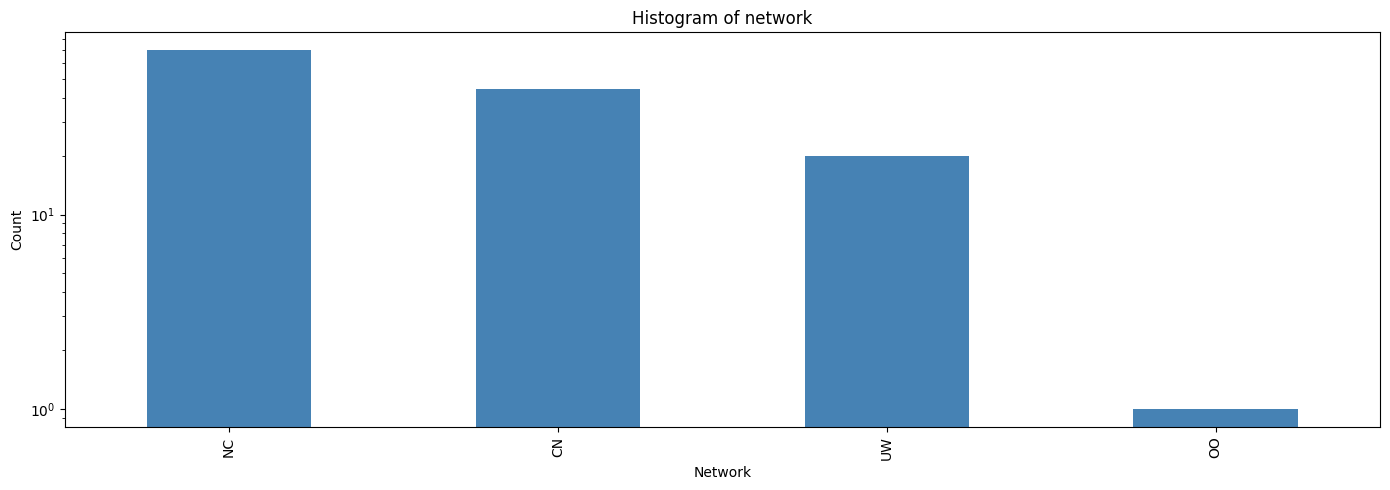

In [7]:
network_counts = skipped_picks_df['network'].value_counts()
ax = network_counts.plot(kind='bar', figsize=(14, 5), color='steelblue')
ax.set_title('Histogram of network')
ax.set_xlabel('Network')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

Calculate the percentage of BK and NC stations in all stations

In [8]:
network_counts

NC    70
CN    44
UW    20
OO     1
Name: network, dtype: int64

In [10]:
network_counts.keys()

Index(['NC', 'CN', 'UW', 'OO'], dtype='object')

In [17]:
# Count the total number of stations whose picks were skipped
counts_summed = network_counts.sum()
counts_summed

135

Count the reasons the specific stations and times were skipped during the amplitude calculation

In [12]:
reason_counts = skipped_picks_df['reason'].value_counts()
reason_counts

Request failed: No data available for request.\nHTTP Status code: 204\nDetailed response of server:\n\n                                7
Request failed: No Vertical Component Data Present at NC.KMR with HHZ, BHZ or EHZ channels at 2015-04-24T02:15:28.330000Z. Skipping    1
Request failed: No Vertical Component Data Present at NC.KMR with HHZ, BHZ or EHZ channels at 2015-04-24T02:14:56.100000Z. Skipping    1
Request failed: No Vertical Component Data Present at NC.KMR with HHZ, BHZ or EHZ channels at 2015-04-24T01:36:10.420000Z. Skipping    1
Request failed: No Vertical Component Data Present at NC.KCT with HHZ, BHZ or EHZ channels at 2015-04-21T10:12:56.670000Z. Skipping    1
                                                                                                                                      ..
Request failed: No Vertical Component Data Present at CN.BTB with HHZ, BHZ or EHZ channels at 2012-06-27T08:11:05.690000Z. Skipping    1
Request failed: No Vertical Component Dat

In [13]:
skipped_picks_df_v_comp = skipped_picks_df[skipped_picks_df['reason'].str.contains('Request failed: No Vertical Component Data Present',na=False)]
print('len(skipped_picks_df_v_comp): ', len(skipped_picks_df_v_comp))
skipped_picks_df_v_comp.head()

len(skipped_picks_df_v_comp):  126


,arid,orid,network,station,channel,origin_time,time_pick,starttime,endtime,reason,network_station
0,43526,3191,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:05.360000Z,2010-04-30T16:04:05.360000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
1,43666,3204,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:27.850000Z,2010-05-01T04:21:27.850000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
2,58950,4249,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:07.870000Z,2010-06-22T15:52:07.870000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
3,71607,5135,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:04:32.760000Z,2010-07-31T04:07:32.760000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
4,74595,5329,UW,SP2,*H*,2010-08-09T03:50:22.194000Z,2010-08-09T03:50:52.920000Z,2010-08-09T03:50:22.920000Z,2010-08-09T03:53:22.920000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.


In [14]:
len(skipped_picks_df)

135